
# Modelo de Clasificación para la Predicción de Fuga de Clientes en Marketplaces

**Objetivo:** Desarrollar un modelo de aprendizaje supervisado que identifique clientes con baja probabilidad de retorno, utilizando variables como el tiempo entre compras y la calificación de sus pedidos anteriores.

**Motivación:** Retener un cliente existente es significativamente menos costoso que adquirir uno nuevo. En plataformas de e-commerce masivo, la insatisfacción del usuario rara vez se expresa de forma explícita. Este modelo permite al equipo de marketing automatizar campañas de recuperación dirigidas únicamente a usuarios en riesgo, optimizando el presupuesto publicitario.

**Dataset:** Brazilian E-Commerce Public Dataset — Olist. 126 MB, ~100.000 pedidos entre 2016 y 2018, distribuidos en 9 archivos CSV con información de pedidos, clientes, reseñas, pagos, productos, vendedores y geolocalización.

---

## Flujo del proyecto

| Etapa | Descripción |
|---|---|
| 1 | Carga y exploración de los 9 CSV |
| 2 | Análisis de calidad por dataset |
| 3 | Análisis exploratorio visual (EDA) |
| 4 | Ingeniería de características y construcción del dataset de modelado |
| 5 | Entrenamiento y evaluación de modelos de clasificación |
| 6 | Interpretación de resultados y recomendaciones de negocio |



## Sección 0 — Importaciones y Carga de Datos

Se configuran las librerías necesarias para el análisis: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización, y los módulos de `scikit-learn` que se usarán en el modelado.

A continuación se cargan los 9 archivos CSV directamente desde su ruta local en el entorno de Colab. Cada dataset se almacena en una variable con nombre descriptivo en español. Al finalizar la carga se imprime el shape de cada DataFrame como verificación.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rutas de los archivos
path_prefix = '/content/'

# Carga de los 9 datasets de Olist
df_clientes = pd.read_csv(f'{path_prefix}olist_customers_dataset.csv', encoding='utf-8')
df_items_pedido = pd.read_csv(f'{path_prefix}olist_order_items_dataset.csv', encoding='utf-8')
df_pagos_pedido = pd.read_csv(f'{path_prefix}olist_order_payments_dataset.csv', encoding='utf-8')
df_resenas_pedido = pd.read_csv(f'{path_prefix}olist_order_reviews_dataset.csv', encoding='utf-8')
df_pedidos = pd.read_csv(f'{path_prefix}olist_orders_dataset.csv', encoding='utf-8')
df_productos = pd.read_csv(f'{path_prefix}olist_products_dataset.csv', encoding='utf-8')
df_vendedores = pd.read_csv(f'{path_prefix}olist_sellers_dataset.csv', encoding='utf-8')
df_geolocalizacion = pd.read_csv(f'{path_prefix}olist_geolocation_dataset.csv', encoding='utf-8')
df_traduccion_categorias = pd.read_csv(f'{path_prefix}product_category_name_translation.csv', encoding='utf-8')

# Diccionario para iterar y mostrar dimensiones
datasets = {
    'Clientes': df_clientes,
    'Items de Pedido': df_items_pedido,
    'Pagos de Pedido': df_pagos_pedido,
    'Reseñas de Pedido': df_resenas_pedido,
    'Pedidos': df_pedidos,
    'Productos': df_productos,
    'Vendedores': df_vendedores,
    'Geolocalización': df_geolocalizacion,
    'Traducción de Categorías': df_traduccion_categorias
}

print('Dimensiones de los DataFrames cargados:')
for nombre, df in datasets.items():
    print(f'{nombre}: {df.shape}')

Dimensiones de los DataFrames cargados:
Clientes: (99441, 5)
Items de Pedido: (112650, 7)
Pagos de Pedido: (103886, 5)
Reseñas de Pedido: (99224, 7)
Pedidos: (99441, 8)
Productos: (32951, 9)
Vendedores: (3095, 4)
Geolocalización: (1000163, 5)
Traducción de Categorías: (71, 2)


## Sección 1 — Exploración Inicial y Calidad de Datos

Antes de cualquier análisis, se audita la integridad técnica de todos los datasets de forma sistemática. Para cada uno se revisa: tipos de datos por columna, cantidad y porcentaje de valores nulos, y número de registros duplicados.

Esta sección permite identificar qué datasets requieren limpieza o tratamiento especial antes de ser utilizados en el modelado, y cuáles se encuentran en condiciones óptimas para su uso directo.

In [ ]:
for nombre, df in datasets.items():
    print(f'\n' + '='*50)
    print(f'ANÁLISIS DE: {nombre}')
    print('='*50)

    print('\n--- Información General ---')
    df.info()

    print('\n--- Valores Nulos por Columna ---')
    nulls = df.isnull().sum()
    print(nulls[nulls > 0] if nulls.sum() > 0 else 'No hay valores nulos.')

    print('\n--- Registros Duplicados ---')
    print(f'Total duplicados: {df.duplicated().sum()}')

print('\n' + '='*50)
print('VISTA PREVIA DE DATAFRAMES PRINCIPALES')
print('='*50)
print('\nPrimeras filas de Clientes:')
display(df_clientes.head())

print('\nPrimeras filas de Pedidos:')
display(df_pedidos.head())


ANÁLISIS DE: Clientes

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- Valores Nulos por Columna ---
No hay valores nulos.

--- Registros Duplicados ---
Total duplicados: 0

ANÁLISIS DE: Items de Pedido

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 n

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Primeras filas de Pedidos:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Sección 2.1 — Análisis de Clientes

Se analiza el dataset de clientes (`olist_customers_dataset.csv`), que contiene la información geográfica y de identificación de cada comprador.

Un aspecto clave es la distinción entre `customer_id` (identificador único por pedido) y `customer_unique_id` (identificador único por persona). Esta diferencia es fundamental para el modelo: permite identificar clientes recurrentes y calcular correctamente métricas como frecuencia de compra y tiempo entre pedidos.

In [ ]:
print('--- Información de Tipos de Datos y Nulos ---')
print(df_clientes.info())

print('\n--- Verificación de Nulos y Duplicados ---')
print(f'Valores nulos totales: {df_clientes.isnull().sum().sum()}')
print(f'Registros duplicados totales: {df_clientes.duplicated().sum()}')

print('\n--- Análisis de Identificadores Únicos ---')
# customer_id: ID que identifica la relación entre un cliente y un pedido (ID por pedido/transacción)
# customer_unique_id: ID único que identifica al cliente real en la plataforma a través del tiempo
print(f'Total de customer_id (transaccionales): {df_clientes["customer_id"].nunique()}')
print(f'Total de customer_unique_id (clientes únicos): {df_clientes["customer_unique_id"].nunique()}')

# Documentación de columnas:
# customer_id: Clave primaria para unir con la tabla de pedidos.
# customer_unique_id: Clave para rastrear el historial de compras de un mismo usuario (vital para churn).
# customer_zip_code_prefix: Los primeros 5 dígitos del código postal del cliente.
# customer_city: Nombre de la ciudad de residencia del cliente.
# customer_state: Sigla del estado de residencia del cliente.

df_clientes.head()

--- Información de Tipos de Datos y Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- Verificación de Nulos y Duplicados ---
Valores nulos totales: 0
Registros duplicados totales: 0

--- Análisis de Identificadores Únicos ---
Total de customer_id (transaccionales): 99441
Total de customer_unique_id (clientes únicos): 96096


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Sección 2.2 — Análisis de Ítems de Pedido

Se examina el dataset de ítems (`olist_order_items_dataset.csv`), que detalla los productos incluidos en cada pedido junto con su precio y costo de envío.

Se calculan estadísticas descriptivas para `price` y `freight_value`, y se identifican valores atípicos mediante boxplots. Esta revisión es relevante porque los outliers en precio pueden distorsionar las métricas de valor monetario que se usarán como features en el modelo.

--- Información General de Items de Pedido ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Valores nulos:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- Estadísticas Descriptivas (Price & Freight) ---


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


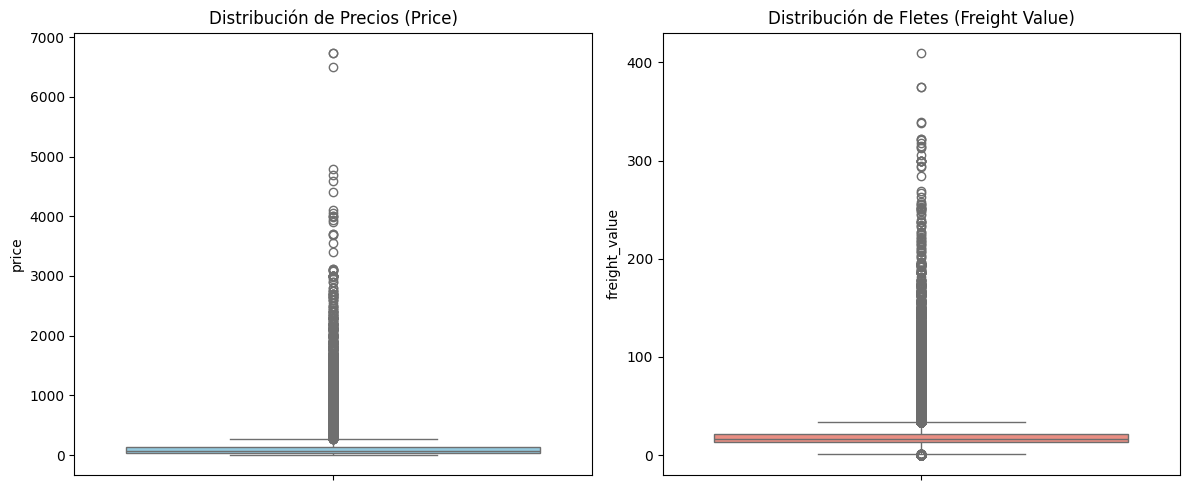


--- Registros con Precios más altos ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34



--- Registros con Fletes más altos ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30


In [ ]:
# 1. Información general y nulos
print('--- Información General de Items de Pedido ---')
print(df_items_pedido.info())
print(f'\nValores nulos:\n{df_items_pedido.isnull().sum()}')

# 2. Estadísticas descriptivas
print('\n--- Estadísticas Descriptivas (Price & Freight) ---')
display(df_items_pedido[['price', 'freight_value']].describe())

# 3. Visualización de Outliers (Boxplots)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_items_pedido['price'], color='skyblue')
plt.title('Distribución de Precios (Price)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_items_pedido['freight_value'], color='salmon')
plt.title('Distribución de Fletes (Freight Value)')

plt.tight_layout()
plt.show()

# 4. Identificación de valores altos
print('\n--- Registros con Precios más altos ---')
display(df_items_pedido.nlargest(5, 'price'))

print('\n--- Registros con Fletes más altos ---')
display(df_items_pedido.nlargest(5, 'freight_value'))

# 5. Documentación de columnas clave
# order_id: ID del pedido, permite unir con 'df_pedidos' y 'df_pagos_pedido'.
# order_item_id: Número secuencial que identifica el número de artículos dentro del mismo pedido.
# product_id: ID del producto, permite unir con 'df_productos'.
# seller_id: ID del vendedor, permite unir con 'df_vendedores'.
# price: Precio de venta del producto.
# freight_value: Valor del flete (envío).

## Sección 2.3 — Análisis de Pagos

Se analiza el dataset de pagos (`olist_order_payments_dataset.csv`), que registra el método de pago, el número de cuotas y el valor total de cada transacción.

Se visualiza la distribución de métodos de pago y la cantidad de cuotas elegidas por los clientes. La variable `payment_value` se usará como indicador de valor monetario en el perfil RFM de cada cliente.

--- Información General de Pagos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None

--- Verificación de Nulos y Duplicados ---
Nulos:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Total duplicados: 0

--- Estadísticas Descriptivas ---


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


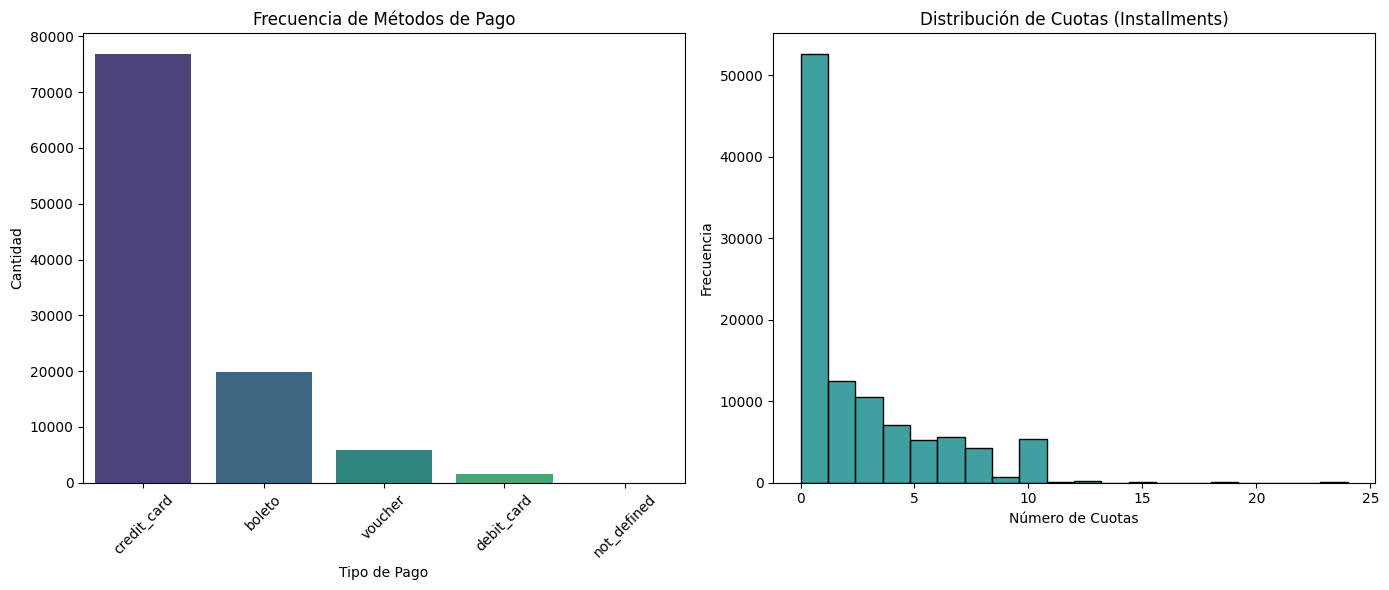


--- Documentación de Columnas Principales ---


In [ ]:
print('--- Información General de Pagos ---')
print(df_pagos_pedido.info())

print('\n--- Verificación de Nulos y Duplicados ---')
print(f'Nulos:\n{df_pagos_pedido.isnull().sum()}')
print(f'\nTotal duplicados: {df_pagos_pedido.duplicated().sum()}')

print('\n--- Estadísticas Descriptivas ---')
display(df_pagos_pedido[['payment_sequential', 'payment_installments', 'payment_value']].describe())

# Visualización de Métodos de Pago
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df_pagos_pedido, x='payment_type', order=df_pagos_pedido['payment_type'].value_counts().index, hue='payment_type', palette='viridis', legend=False)
plt.title('Frecuencia de Métodos de Pago')
plt.xlabel('Tipo de Pago')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)

# Visualización de Cuotas
plt.subplot(1, 2, 2)
sns.histplot(df_pagos_pedido['payment_installments'], bins=20, kde=False, color='teal')
plt.title('Distribución de Cuotas (Installments)')
plt.xlabel('Número de Cuotas')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\n--- Documentación de Columnas Principales ---')
# order_id: ID único del pedido, clave para unir con la tabla de pedidos.
# payment_type: Método de pago utilizado por el cliente (ej. tarjeta de crédito, boleto).
# payment_value: Monto total pagado en la transacción.
# payment_installments: Cantidad de cuotas elegidas por el cliente para el pago.

## Sección 2.4 — Análisis de Reseñas

Se estudia el dataset de reseñas (`olist_order_reviews_dataset.csv`), que contiene la calificación numérica (`review_score`) y los comentarios opcionales dejados por los clientes tras recibir sus pedidos.

Se analiza la distribución de puntajes, el porcentaje de reseñas sin comentario escrito, y la relación entre la presencia de texto y la calificación otorgada. El `review_score` es una de las variables más importantes del modelo, ya que actúa como señal directa de satisfacción del cliente.

--- Distribuci2n de Puntajes de Rese$a (review_score) ---
              Frecuencia  Porcentaje (%)
review_score                            
1                  11424       11.513344
2                   3151        3.175643
3                   8179        8.242965
4                  19142       19.291704
5                  57328       57.776344

--- An!lisis de Valores Nulos en Textos ---
T$tulos nulos: 87656 (88.34%)
Mensajes nulos: 58247 (58.70%)


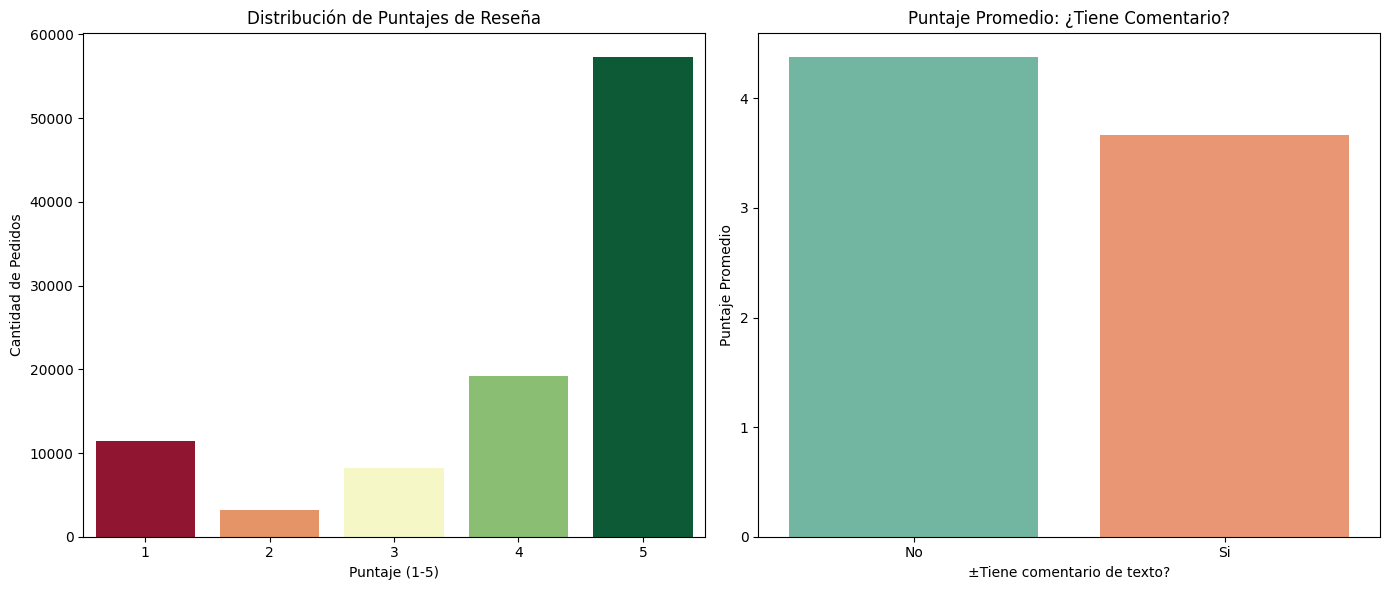

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('--- Distribuci2n de Puntajes de Rese$a (review_score) ---')
score_counts = df_resenas_pedido['review_score'].value_counts().sort_index()
score_perc = df_resenas_pedido['review_score'].value_counts(normalize=True).sort_index() * 100
df_score_dist = pd.DataFrame({'Frecuencia': score_counts, 'Porcentaje (%)': score_perc})
print(df_score_dist)

print('\n--- An!lisis de Valores Nulos en Textos ---')
null_title = df_resenas_pedido['review_comment_title'].isnull().sum()
null_message = df_resenas_pedido['review_comment_message'].isnull().sum()
total_rows = len(df_resenas_pedido)
print(f'T$tulos nulos: {null_title} ({null_title/total_rows*100:.2f}%)')
print(f'Mensajes nulos: {null_message} ({null_message/total_rows*100:.2f}%)')

# Crear columna booleana para presencia de mensaje
df_resenas_pedido['has_comment'] = df_resenas_pedido['review_comment_message'].notnull()

# Configuraci3n de visualizaciones
plt.figure(figsize=(14, 6))

# 1. Distribuci3n de review_score
plt.subplot(1, 2, 1)
sns.countplot(data=df_resenas_pedido, x='review_score', hue='review_score', palette='RdYlGn', legend=False)
plt.title('Distribución de Puntajes de Reseña')
plt.xlabel('Puntaje (1-5)')
plt.ylabel('Cantidad de Pedidos')

# 2. Puntaje promedio con vs sin comentario
plt.subplot(1, 2, 2)
avg_score_comment = df_resenas_pedido.groupby('has_comment')['review_score'].mean().reset_index()
sns.barplot(data=avg_score_comment, x='has_comment', y='review_score', hue='has_comment', palette='Set2', legend=False)
plt.title('Puntaje Promedio: ¿Tiene Comentario?')
plt.xlabel('±Tiene comentario de texto?')
plt.ylabel('Puntaje Promedio')
plt.xticks([0, 1], ['No', 'Si'])

plt.tight_layout()
plt.show()

## Sección 2.5 — Análisis de Pedidos

Se audita el dataset central del proyecto (`olist_orders_dataset.csv`), que registra el ciclo de vida completo de cada pedido: desde la compra hasta la entrega.

Se convierten todas las columnas de fecha a formato `datetime`, se analiza la distribución de estados de pedido (`order_status`), y se verifican valores nulos en los timestamps. Esta tabla conecta clientes, productos, pagos y reseñas a través del `order_id`.

In [ ]:
import pandas as pd

# 1. Identificar columnas de marcas de tiempo
date_columns = [col for col in df_pedidos.columns if col.endswith(('_timestamp', '_at', '_date'))]
print(f'Columnas de fecha detectadas: {date_columns}')

# 2. Convertir a datetime
for col in date_columns:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

print('\n--- Verificación de Tipos de Datos (Post-conversión) ---')
print(df_pedidos[date_columns].dtypes)

# 3. Frecuencia de estados de pedido
print('\n--- Frecuencia de Estados de Pedido (order_status) ---')
status_counts = df_pedidos['order_status'].value_counts()
status_perc = df_pedidos['order_status'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Frecuencia': status_counts, 'Porcentaje (%)': status_perc}))

# 4. Verificación de nulos en columnas de fechas
print('\n--- Verificación de Nulos en Timestamps ---')
null_dates = df_pedidos[date_columns].isnull().sum()
print(null_dates)

# 5. Mostrar primeras filas
print('\n--- Vista Previa de df_pedidos ---')
display(df_pedidos.head())

Columnas de fecha detectadas: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- Verificación de Tipos de Datos (Post-conversión) ---
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

--- Frecuencia de Estados de Pedido (order_status) ---


,Frecuencia,Porcentaje (%)
order_status,,
delivered,96478,97.020344
shipped,1107,1.113223
canceled,625,0.628513
unavailable,609,0.612423
invoiced,314,0.315765
processing,301,0.302692
created,5,0.005028
approved,2,0.002011



--- Verificación de Nulos en Timestamps ---
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- Vista Previa de df_pedidos ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Sección 2.6 — Análisis de Productos

Se inspecciona el dataset de productos (`olist_products_dataset.csv`), que contiene el nombre de categoría, dimensiones físicas y peso de cada artículo del catálogo.

Se identifican nulos en la columna de categoría y en las dimensiones físicas, y se calcula la diversidad del catálogo. La categoría de producto más frecuente por cliente se usará como feature adicional en el modelo de clasificación.


In [ ]:
import pandas as pd

# 1. Conteo detallado de valores nulos
print('--- Valores Nulos en df_productos ---')
print(df_productos.isnull().sum())

# 2. Diversidad del catálogo (Categorías únicas)
unique_categories = df_productos['product_category_name'].nunique()
print(f'\nTotal de categorías únicas: {unique_categories}')

# 3. Estadísticas descriptivas de dimensiones y peso
print('\n--- Estadísticas Descriptivas de Dimensiones y Peso ---')
physical_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
display(df_productos[physical_cols].describe())

# 4. Top 10 categorías con más productos
print('\n--- Top 10 Categorías (Concentración de Inventario) ---')
top_10_categories = df_productos['product_category_name'].value_counts().head(10)
print(top_10_categories)

# 5. Documentación de campos críticos
# product_category_name: Crucial para segmentación de clientes y análisis de preferencias.
# product_weight_g & dimensiones: Críticos para logística, cálculo de fletes y eficiencia de envío.
# product_id: Clave primaria para unir con items de pedido.

--- Valores Nulos en df_productos ---
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Total de categorías únicas: 73

--- Estadísticas Descriptivas de Dimensiones y Peso ---


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000



--- Top 10 Categorías (Concentración de Inventario) ---
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


##  Sección 2.7 — Análisis de Vendedores

Se examina el dataset de vendedores (`olist_sellers_dataset.csv`), que registra la ubicación geográfica de cada vendedor por ciudad y estado.

Se calcula la concentración de vendedores por estado y se visualizan los 10 estados con mayor presencia. Esta distribución permite entender si la cobertura logística puede influir en la experiencia del cliente y en su probabilidad de fuga.

--- Calidad de Datos en df_vendedores ---
Valores nulos:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Registros duplicados: 0

--- Concentración de Vendedores por Estado ---
              Cantidad  Porcentaje (%)
seller_state                          
SP                1849           59.74
PR                 349           11.28
MG                 244            7.88
SC                 190            6.14
RJ                 171            5.53
RS                 129            4.17
GO                  40            1.29
DF                  30            0.97
ES                  23            0.74
BA                  19            0.61

Total de ciudades únicas con vendedores: 611


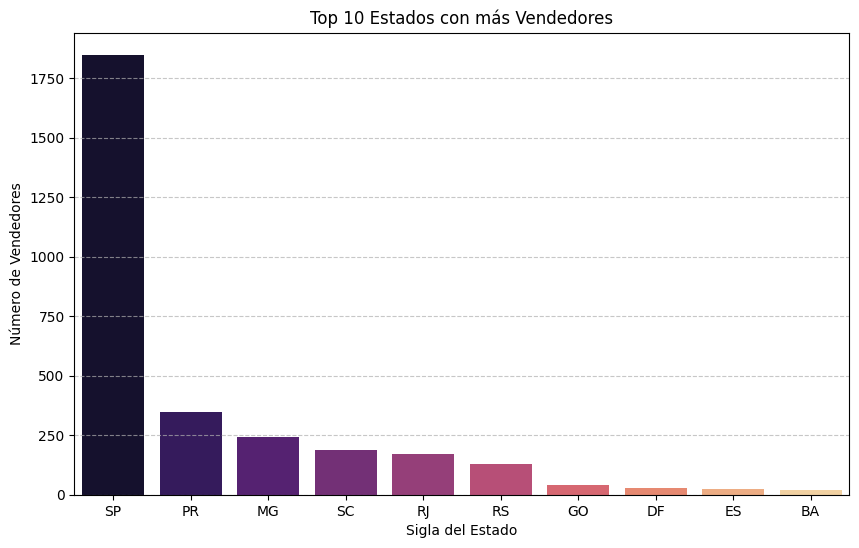

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inspección técnica inicial
print('--- Calidad de Datos en df_vendedores ---')
print(f'Valores nulos:\n{df_vendedores.isnull().sum()}')
print(f'\nRegistros duplicados: {df_vendedores.duplicated().sum()}')

# 2. Frecuencia y porcentaje por estado
state_counts = df_vendedores['seller_state'].value_counts()
state_percs = (df_vendedores['seller_state'].value_counts(normalize=True) * 100).round(2)
df_state_dist = pd.DataFrame({'Cantidad': state_counts, 'Porcentaje (%)': state_percs})

print('\n--- Concentración de Vendedores por Estado ---')
print(df_state_dist.head(10))

# 3. Ciudades únicas
unique_cities = df_vendedores['seller_city'].nunique()
print(f'\nTotal de ciudades únicas con vendedores: {unique_cities}')

# 4. Visualización del Top 10 de estados
plt.figure(figsize=(10, 6))
sns.barplot(x=state_counts.head(10).index, y=state_counts.head(10).values, hue=state_counts.head(10).index, palette='magma', legend=False)
plt.title('Top 10 Estados con más Vendedores')
plt.xlabel('Sigla del Estado')
plt.ylabel('Número de Vendedores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Documentación de columnas
# seller_id: Clave primaria del vendedor. Fundamental para unir con df_items_pedido y rastrear el origen de los productos vendidos.
# seller_zip_code_prefix: Prefijo del código postal, útil para análisis logísticos y de proximidad.
# seller_city/state: Información geográfica para segmentación regional.

## Sección 2.8 — Análisis de Geolocalización

Se audita el dataset de geolocalización (`olist_geolocation_dataset.csv`), que mapea códigos postales brasileños a coordenadas de latitud y longitud.

Este dataset contiene duplicados por diseño (múltiples coordenadas por ZIP), por lo que se eliminan los registros redundantes y se validan los rangos geográficos válidos para Brasil. Se usa principalmente para enriquecer visualizaciones de densidad de clientes.

In [ ]:
print(f'Registros iniciales en Geocalización: {len(df_geolocalizacion)}')

# 1. Eliminar duplicados exactos
df_geolocalizacion = df_geolocalizacion.drop_duplicates()
print(f'Registros tras eliminar duplicados exactos: {len(df_geolocalizacion)}')

# 2. Estadísticas descriptivas de coordenadas
print('\n--- Estadísticas de Coordenadas ---')
display(df_geolocalizacion[['geolocation_lat', 'geolocation_lng']].describe())

# 3. Optimización: Mantener una coordenada única (promedio) por código postal
# Esto es útil para evitar explosión de filas al unir por zip_code_prefix
df_geo_unique = df_geolocalizacion.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# 4. Informe final
print('\n--- Resumen Final de Geolocalización ---')
print(f'Total de prefijos de código postal únicos: {len(df_geo_unique)}')
print(f'Rango Latitud: {df_geo_unique["geolocation_lat"].min():.4f} a {df_geo_unique["geolocation_lat"].max():.4f}')
print(f'Rango Longitud: {df_geo_unique["geolocation_lng"].min():.4f} a {df_geo_unique["geolocation_lng"].max():.4f}')

display(df_geo_unique.head())

Registros iniciales en Geocalización: 1000163
Registros tras eliminar duplicados exactos: 738332

--- Estadísticas de Coordenadas ---


,geolocation_lat,geolocation_lng
count,738332.000000,738332.000000
mean,-20.998353,-46.461098
std,5.892315,4.393705
min,-36.605374,-101.466766
25%,-23.603061,-48.867822
50%,-22.873588,-46.647278
75%,-19.923336,-43.836974
max,45.065933,121.105394



--- Resumen Final de Geolocalización ---
Total de prefijos de código postal únicos: 19015
Rango Latitud: -33.6899 a 42.1840
Rango Longitud: -72.9161 a 121.1054


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550227,-46.634039,sao paulo,SP
1,1002,-23.547657,-46.634991,sao paulo,SP
2,1003,-23.549000,-46.635582,sao paulo,SP
3,1004,-23.549829,-46.634792,sao paulo,SP
4,1005,-23.549547,-46.636406,sao paulo,SP


## Sección 2.9 — Traducción de Categorías

Se verifica el dataset de traducción (`product_category_name_translation.csv`), que mapea los nombres de categorías del portugués al inglés.

Se comparan las categorías presentes en este archivo con las del catálogo de productos para identificar categorías sin traducción disponible. Este mapeo se aplica en el EDA para que las visualizaciones sean comprensibles por cualquier audiencia.

In [ ]:
print('--- Información General de Traducción de Categorías ---')
print(df_traduccion_categorias.info())
print(f'\nValores nulos:\n{df_traduccion_categorias.isnull().sum()}')

# 1. Obtener categorías únicas de ambos datasets
cats_productos = set(df_productos['product_category_name'].dropna().unique())
cats_traduccion = set(df_traduccion_categorias['product_category_name'].unique())

# 2. Identificar categorías sin traducción
cats_sin_traduccion = cats_productos - cats_traduccion
print(f'\nTotal de categorías en productos: {len(cats_productos)}')
print(f'Total de categorías en traducción: {len(cats_traduccion)}')
print(f'Categorías sin traducción encontrada: {len(cats_sin_traduccion)}')

if len(cats_sin_traduccion) > 0:
    print('\nCategorías faltantes en el archivo de traducción:')
    print(sorted(list(cats_sin_traduccion)))

# 3. Calcular porcentaje de productos afectados
num_productos_sin_trad = df_productos[df_productos['product_category_name'].isin(cats_sin_traduccion)].shape[0]
total_productos = len(df_productos)
porcentaje_afectado = (num_productos_sin_trad / total_productos) * 100

print(f'\n--- Impacto en el Catálogo ---')
print(f'Productos con categorías sin traducción: {num_productos_sin_trad}')
print(f'Porcentaje del catálogo afectado: {porcentaje_afectado:.2f}%')

display(df_traduccion_categorias.head())

--- Información General de Traducción de Categorías ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None

Valores nulos:
product_category_name            0
product_category_name_english    0
dtype: int64

Total de categorías en productos: 73
Total de categorías en traducción: 71
Categorías sin traducción encontrada: 2

Categorías faltantes en el archivo de traducción:
['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']

--- Impacto en el Catálogo ---
Productos con categorías sin traducción: 13
Porcentaje del catálogo afectado: 0.04%


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Sección 3 — Análisis Exploratorio Visual (EDA)

Se generan las visualizaciones principales que resumen el comportamiento del negocio entre 2016 y 2018:

- **Evolución mensual de pedidos:** identifica tendencias de crecimiento y estacionalidad.
- **Estados de pedido (excluyendo entregados):** muestra la proporción de pedidos cancelados o con problemas.
- **Top 10 ciudades con más clientes:** revela la concentración geográfica de la demanda.
- **Distribución del valor de pagos (escala logarítmica):** expone la asimetría del gasto y la presencia de outliers.

Todas las gráficas incluyen títulos y etiquetas de ejes en español.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configurar estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)



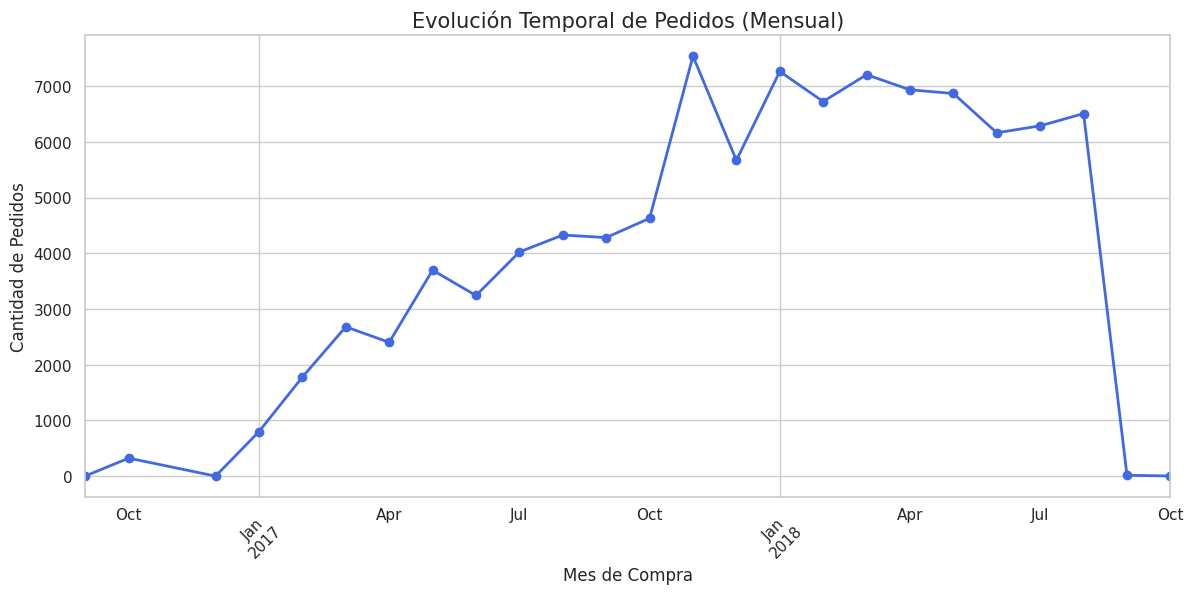

In [ ]:
# 2. Evolución temporal de las ventas (Pedidos por mes)
df_pedidos['order_month'] = df_pedidos['order_purchase_timestamp'].dt.to_period('M')
ventas_mensuales = df_pedidos['order_month'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ventas_mensuales.plot(kind='line', marker='o', color='royalblue', linewidth=2)
plt.title('Evolución Temporal de Pedidos (Mensual)', fontsize=15)
plt.xlabel('Mes de Compra', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.xticks(rotation=45)
plt.show()



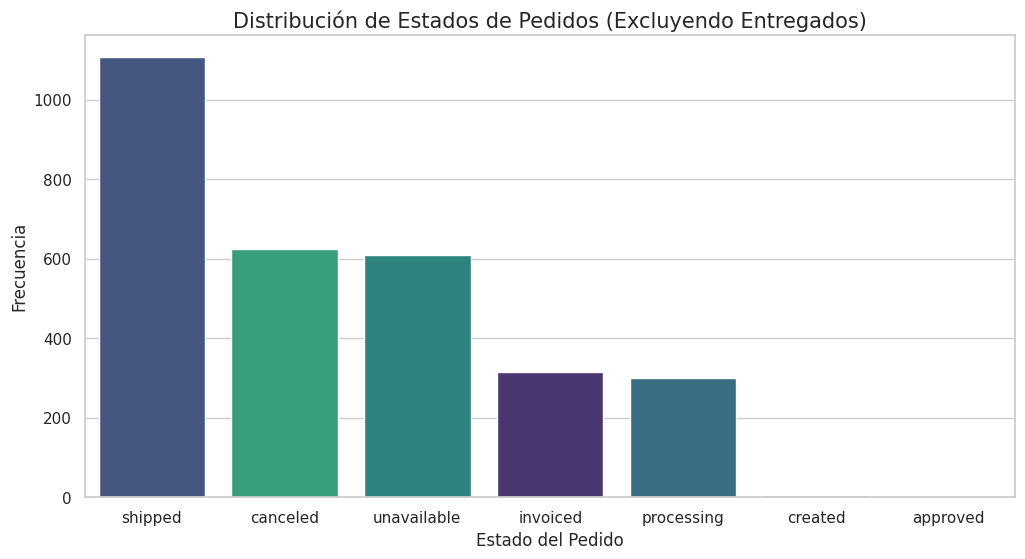

In [ ]:
# 3. Distribución de estados de pedido (excluyendo 'delivered')
df_status_minor = df_pedidos[df_pedidos['order_status'] != 'delivered']

plt.figure(figsize=(12, 6))
sns.countplot(data=df_status_minor, x='order_status', order=df_status_minor['order_status'].value_counts().index, hue='order_status', palette='viridis', legend=False)
plt.title('Distribución de Estados de Pedidos (Excluyendo Entregados)', fontsize=15)
plt.xlabel('Estado del Pedido', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()



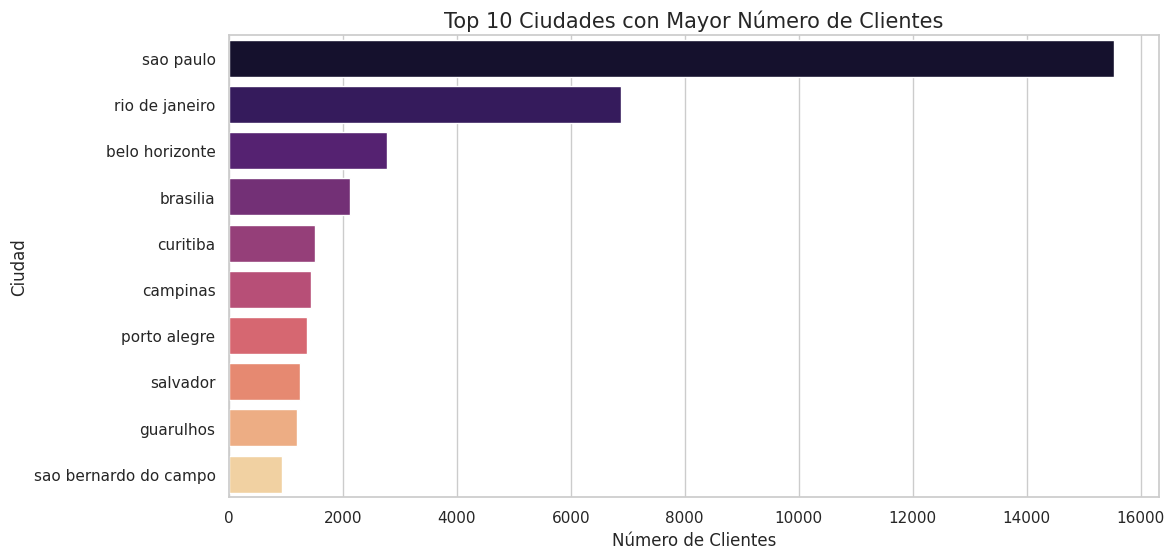

In [ ]:
# 4. Análisis Geográfico: Top 10 Ciudades con más Clientes
top_ciudades = df_clientes['customer_city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_ciudades.values, y=top_ciudades.index, hue=top_ciudades.index, palette='magma', legend=False)
plt.title('Top 10 Ciudades con Mayor Número de Clientes', fontsize=15)
plt.xlabel('Número de Clientes', fontsize=12)
plt.ylabel('Ciudad', fontsize=12)
plt.show()



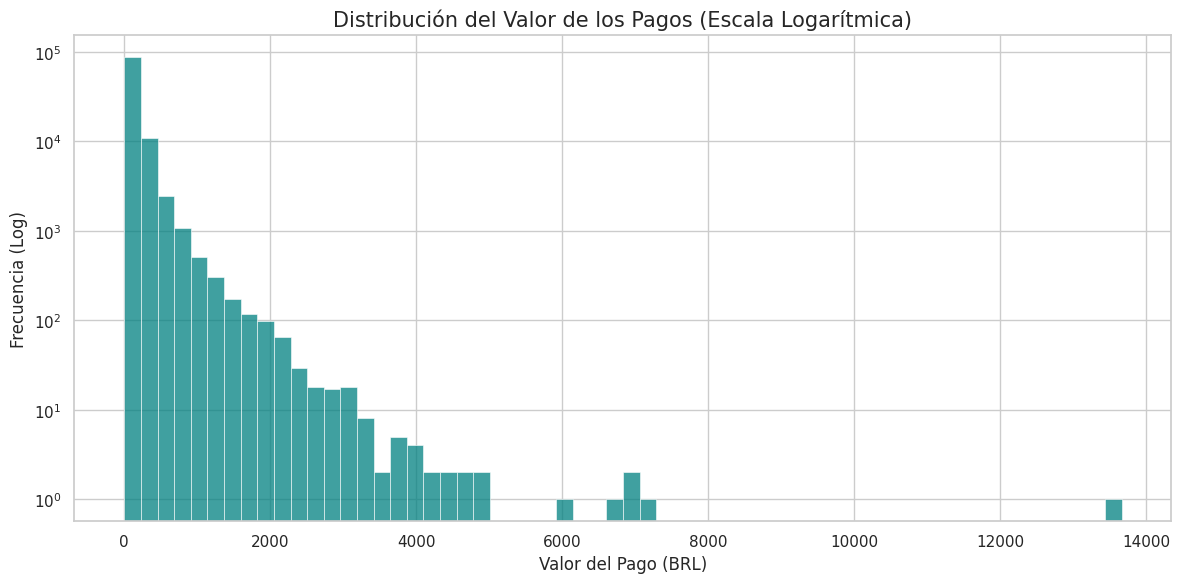

In [ ]:
# 5. Distribución del Valor de los Pagos
plt.figure(figsize=(12, 6))
sns.histplot(
    df_pagos_pedido['payment_value'],
    bins=60,
    kde=False,          # KDE es incompatible con escala log
    color='teal',
    edgecolor='white',
    linewidth=0.4
)
plt.yscale('log')
plt.title('Distribución del Valor de los Pagos (Escala Logarítmica)', fontsize=15)
plt.xlabel('Valor del Pago (BRL)', fontsize=12)
plt.ylabel('Frecuencia (Log)', fontsize=12)
plt.tight_layout()
plt.show()

## Sección 4 — Ingeniería de Características

Se construye el dataset final que alimentará el modelo de clasificación en dos etapas:

**Etapa 1 — Unificación:** merge secuencial de los datasets de clientes, pedidos, ítems, pagos y reseñas usando `customer_id` y `order_id` como llaves, obteniendo un DataFrame maestro de 113.425 filas y 21 columnas.

**Etapa 2 — Agregación por cliente:** a partir del DataFrame maestro se calculan las métricas RFM por `customer_unique_id`:

| Feature | Descripción |
|---|---|
| `recency` | Días desde la última compra |
| `frequency` | Número total de pedidos |
| `monetary` | Gasto acumulado |
| `avg_review_score` | Calificación promedio |
| `most_frequent_category` | Categoría más comprada |

**Variable objetivo:** `churn = 1` si la recencia supera los 180 días, indicando que el cliente no ha regresado en más de 6 meses. El dataset final contiene 96.096 clientes únicos con un desbalance de clases de 70/30, que será tratado en la etapa de modelado.

In [ ]:
import pandas as pd

# 1. Unificar DataFrames principales
# Primero, unir clientes con pedidos
df_maestro = pd.merge(df_clientes, df_pedidos, on='customer_id', how='left')

# Unir con items de pedido
df_maestro = pd.merge(df_maestro, df_items_pedido, on='order_id', how='left')

# Unir con pagos (puede haber varios pagos por pedido, agrupamos para no duplicar filas en el maestro inicial)
df_pagos_agrupados = df_pagos_pedido.groupby('order_id')['payment_value'].sum().reset_index()
df_maestro = pd.merge(df_maestro, df_pagos_agrupados, on='order_id', how='left')

# Unir con reseñas (puntaje promedio por pedido)
df_resenas_agrupadas = df_resenas_pedido.groupby('order_id')['review_score'].mean().reset_index()
df_maestro = pd.merge(df_maestro, df_resenas_agrupadas, on='order_id', how='left')

# 2. Asegurar que las fechas estén en formato datetime
df_maestro['order_purchase_timestamp'] = pd.to_datetime(df_maestro['order_purchase_timestamp'])

print(f'Dimensiones del DataFrame maestro unificado: {df_maestro.shape}')
print('\nPrimeras filas del DataFrame maestro:')
display(df_maestro.head())

Dimensiones del DataFrame maestro unificado: (113425, 21)

Primeras filas del DataFrame maestro:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_estimated_delivery_date,order_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value,review_score
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-06-05,2017-05,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,146.87,4.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-02-06,2018-01,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,335.48,5.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-06-13,2018-05,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,157.73,5.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-04-10,2018-03,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,173.30,5.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-08-15,2018-07,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,252.25,5.0


**Reasoning**:
I will aggregate the data at the customer level (customer_unique_id) to calculate RFM metrics, average review scores, and identify the most frequent product category, followed by the definition of the churn label based on the 180-day threshold.



In [ ]:
import pandas as pd
import numpy as np

# 1. Preparación de datos: Unir con categorías de productos para la moda de categoría
df_maestro = pd.merge(df_maestro, df_productos[['product_id', 'product_category_name']], on='product_id', how='left')

# 2. Definir fecha de referencia (última fecha en el dataset)
max_date = df_maestro['order_purchase_timestamp'].max()

# 3. Agregación por customer_unique_id
# Calculamos Recencia, Frecuencia, Valor, Review Score promedio
df_customers_features = df_maestro.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (max_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum',
    'review_score': 'mean'
}).reset_index()

# Renombrar columnas RFM
df_customers_features.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary', 'avg_review_score']

# 4. Obtener la categoría favorita (la más comprada) por cliente
cat_frecuente = df_maestro.groupby('customer_unique_id')['product_category_name'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'unknown').reset_index()
cat_frecuente.columns = ['customer_unique_id', 'most_frequent_category']

# Unir con el dataframe de características
df_customers_features = pd.merge(df_customers_features, cat_frecuente, on='customer_unique_id', how='left')

# 5. Definir la variable objetivo 'churn' (Fuga)
# Churn = 1 si la recencia es mayor a 180 días
df_customers_features['churn'] = (df_customers_features['recency'] > 180).astype(int)

# 6. Limpieza de nulos
# Rellenar puntaje de reseña faltante con el promedio general si no existe
df_customers_features['avg_review_score'] = df_customers_features['avg_review_score'].fillna(df_customers_features['avg_review_score'].mean())

print(f'Dimensiones finales para modelado: {df_customers_features.shape}')
print('\nDistribución de la variable Churn:')
print(df_customers_features['churn'].value_counts(normalize=True) * 100)

display(df_customers_features.head())

Dimensiones finales para modelado: (96096, 7)

Distribución de la variable Churn:
churn
1    70.882243
0    29.117757
Name: proportion, dtype: float64


,customer_unique_id,recency,frequency,monetary,avg_review_score,most_frequent_category,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,5.0,cama_mesa_banho,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4.0,beleza_saude,0
2,0000f46a3911fa3c0805444483337064,585,1,86.22,3.0,papelaria,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,4.0,telefonia,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,5.0,telefonia,1
